# Ridge Regression (RR) on MALL Feature Set

**Purpose:** This notebook implements the Ridge Regression (RR) model of Hoerl and Kennard (1970) on the MALL feature set for the EURO STOXX 50 index, following the regularized-linear-model approach in Christensen, Siggaard, and Veliyev (2023). Ridge augments the linear volatility-forecasting framework with an L2 penalty that can stabilize coefficient estimates when the predictor set is richer and more collinear than the basic HAR specification.

## 1. Imports

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge

## 2. Data Loading

We use the final `MALL.csv` file as the common data source for all MALL models so the inputs remain aligned across specifications. Within this file, we define a compact “main thesis” MALL predictor set that balances economic coverage, comparability with the reference paper, and manageable computational cost.

In [2]:
# Load MALL dataset
MALL = pd.read_csv('/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/MALL.csv')
MALL['Date'] = pd.to_datetime(MALL['Date'])
MALL = MALL.set_index('Date')

print(f'Sample period: {MALL.index[0].date()} to {MALL.index[-1].date()}')
print(f'Number of observations: {len(MALL)}')
display(MALL[['RVD', 'RVW', 'RVM', 'VSTOXX', 'CISS', 'RV_target']].head())

Sample period: 1999-01-05 to 2020-08-06
Number of observations: 5489


,RVD,RVW,RVM,VSTOXX,CISS,RV_target
Date,,,,,,
1999-01-05,0.000078,0.000093,0.000129,29.6912,0.2085,0.000058
1999-01-06,0.000058,0.000092,0.000123,25.1670,0.2214,0.000139
1999-01-07,0.000139,0.000102,0.000121,32.5205,0.2254,0.000108
1999-01-08,0.000108,0.000106,0.000112,33.2296,0.2297,0.000166
1999-01-11,0.000166,0.000110,0.000110,36.8411,0.2583,0.000115


## 3. Data Split

To remain consistent with the MHAR notebooks, we split the sample into 70% training observations, 10% validation observations, and 20% test observations. The validation set is used to tune the regularization parameters, while the test set is reserved for the final out-of-sample evaluation.

In [3]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(0.70 * n)
n_val = int(0.10 * n)
n_test = n - n_train - n_val

print(f'Training observations:   {n_train}')
print(f'Validation observations: {n_val}')
print(f'Test observations:       {n_test}')

print(f'Training period:   {MALL.index[0].date()} to {MALL.index[n_train - 1].date()}')
print(f'Validation period: {MALL.index[n_train].date()} to {MALL.index[n_train + n_val - 1].date()}')
print(f'Test period:       {MALL.index[n_train + n_val].date()} to {MALL.index[-1].date()}')

Training observations:   3842
Validation observations: 548
Test observations:       1099
Training period:   1999-01-05 to 2014-02-26
Validation period: 2014-02-27 to 2016-04-20
Test period:       2016-04-21 to 2020-08-06


## 4. Feature Set Construction and Standardization

The MALL specification is built from the compact main-thesis feature set proposed for the broader information environment. As in the MHAR notebooks and the reference paper, the regularized regressions are estimated on standardized predictors using moments from the training sample only. The dependent variable remains `RV_target` in levels so the resulting forecasts are directly comparable on the realized-variance scale.

In [4]:
# Define target and main-thesis MALL feature set
y = MALL['RV_target'].values
feature_cols = ['RVD', 'RVW', 'RVM', 'RD_neg', 'RW_neg', 'RM_neg', 'RQ', 'VSTOXX', 'CISS', 'logEPU_1m_lag', 'EURUSD_ret', 'BRENT_ret', 'SP500_ret_lag', 'SP500_sq_lag', 'M1W', 'M1M']
X_MALL = MALL[feature_cols].values

# Split into train, validation and test sets
X_train = X_MALL[:n_train]
X_val = X_MALL[n_train:n_train + n_val]
X_test = X_MALL[n_train + n_val:]

y_train = y[:n_train]
y_val = y[n_train:n_train + n_val]
y_test = y[n_train + n_val:]

# Compute standardization parameters from training set only
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_std = np.where(X_std == 0, 1.0, X_std)

# Scale full dataset using training-sample parameters
X_scaled = (X_MALL - X_mean) / X_std

X_train_scaled = X_scaled[:n_train]
X_val_scaled = X_scaled[n_train:n_train + n_val]
X_test_scaled = X_scaled[n_train + n_val:]

print('Feature set: RVD, RVW, RVM, RD_neg, RW_neg, RM_neg, RQ, VSTOXX, CISS, logEPU_1m_lag, EURUSD_ret, BRENT_ret, SP500_ret_lag, SP500_sq_lag, M1W, M1M')
print(f'\nNumber of predictors: {len(feature_cols)}')
print(f'Full dataset:   X={X_scaled.shape}, y={y.shape}')
print(f'Training set:   X={X_train_scaled.shape}, y={y_train.shape}')
print(f'Validation set: X={X_val_scaled.shape}, y={y_val.shape}')
print(f'Test set:       X={X_test_scaled.shape}, y={y_test.shape}')
print('\nStandardization check on training sample:')
print(f'  Means: {X_train_scaled.mean(axis=0).round(6)}')
print(f'  Std:   {X_train_scaled.std(axis=0).round(6)}')
print('\nPredictor order:')
for j, col in enumerate(feature_cols, start=1):
    print(f'  {j:>2d}. {col}')

Feature set: RVD, RVW, RVM, RD_neg, RW_neg, RM_neg, RQ, VSTOXX, CISS, logEPU_1m_lag, EURUSD_ret, BRENT_ret, SP500_ret_lag, SP500_sq_lag, M1W, M1M

Number of predictors: 16
Full dataset:   X=(5489, 16), y=(5489,)
Training set:   X=(3842, 16), y=(3842,)
Validation set: X=(548, 16), y=(548,)
Test set:       X=(1099, 16), y=(1099,)

Standardization check on training sample:
  Means: [-0.  0. -0.  0. -0. -0. -0. -0.  0.  0. -0.  0.  0. -0.  0.  0.]
  Std:   [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Predictor order:
   1. RVD
   2. RVW
   3. RVM
   4. RD_neg
   5. RW_neg
   6. RM_neg
   7. RQ
   8. VSTOXX
   9. CISS
  10. logEPU_1m_lag
  11. EURUSD_ret
  12. BRENT_ret
  13. SP500_ret_lag
  14. SP500_sq_lag
  15. M1W
  16. M1M


## 5. Hyperparameter Tuning on the Validation Set

Regularized linear models require validation-based tuning. We therefore keep the training and validation samples separate in this step and select the hyperparameters that minimize validation MSE.

Grid size: 1000
Alpha range: 1.00e-05 to 1.00e+02
Optimal alpha: 1.000000e+02
Validation MSE: 1.596539e-08
Position in grid: 999 / 1000


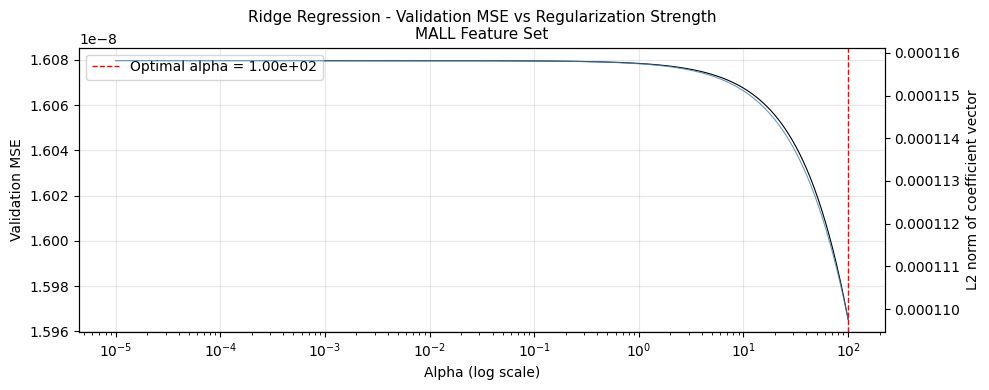

In [5]:
# Define ridge penalty grid following the paper
alpha_grid = np.logspace(-5, 2, 1000)

val_mse = []
coef_norms = []

for alpha in alpha_grid:
    model = Ridge(alpha=alpha, fit_intercept=True)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    val_mse.append(np.mean((y_val - y_pred) ** 2))
    coef_norms.append(np.linalg.norm(model.coef_, ord=2))

best_idx = int(np.argmin(val_mse))
optimal_alpha = alpha_grid[best_idx]
optimal_val_mse = val_mse[best_idx]

print(f"Grid size: {len(alpha_grid)}")
print(f"Alpha range: {alpha_grid[0]:.2e} to {alpha_grid[-1]:.2e}")
print(f"Optimal alpha: {optimal_alpha:.6e}")
print(f"Validation MSE: {optimal_val_mse:.6e}")
print(f"Position in grid: {best_idx} / {len(alpha_grid)}")
if best_idx == 0:
    print("Warning: optimum is at the lower boundary.")
elif best_idx == len(alpha_grid) - 1:
    print("Warning: optimum is at the upper boundary.")
else:
    print("Optimal alpha is an interior point of the grid.")

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.semilogx(alpha_grid, val_mse, color='black', linewidth=0.8)
ax1.axvline(optimal_alpha, color='red', linestyle='--', linewidth=1.0, label=f'Optimal alpha = {optimal_alpha:.2e}')
ax1.set_xlabel('Alpha (log scale)')
ax1.set_ylabel('Validation MSE')
ax1.set_title('Ridge Regression - Validation MSE vs Regularization Strength\nMALL Feature Set', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.semilogx(alpha_grid, coef_norms, color='steelblue', linewidth=0.8, alpha=0.8)
ax2.set_ylabel('L2 norm of coefficient vector')
plt.tight_layout()
plt.show()

## 6. Rolling Out-of-Sample Forecasting

After tuning, we keep the selected hyperparameters fixed and re-estimate the model in a rolling window of length `n_train + n_val`, exactly as in the MHAR regularized-model notebooks. Each iteration produces a one-day-ahead forecast for the next observation in the test set.

In [6]:
fixed_alpha = optimal_alpha
window_size = n_train + n_val

print(f'Fixed alpha from validation tuning: {fixed_alpha:.6e}')
print(f'Rolling window length: {window_size}')

forecasts_RR = []
dates_test = []
coef_norm_path = []

start_time = time.time()

for i in range(n_test):
    X_window = X_scaled[i:i + window_size]
    y_window = y[i:i + window_size]

    model_final = Ridge(alpha=fixed_alpha, fit_intercept=True)
    model_final.fit(X_window, y_window)

    X_forecast = X_scaled[i + window_size].reshape(1, -1)
    forecast = model_final.predict(X_forecast)[0]
    forecast = max(forecast, y_window.min())

    forecasts_RR.append(forecast)
    dates_test.append(MALL.index[i + window_size])
    coef_norm_path.append(np.linalg.norm(model_final.coef_, ord=2))

    if (i + 1) % 100 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f'  Day {i + 1:4d}/{n_test} | Date: {MALL.index[i + window_size].date()} | Elapsed: {elapsed:.1f} min')

total_elapsed = (time.time() - start_time) / 60
print(f'\nTotal estimation time: {total_elapsed:.1f} minutes')
print(f'Forecasts generated: {len(forecasts_RR)}')
print(f'Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}')
print(f'Average coefficient L2 norm: {np.mean(coef_norm_path):.6f}')

Fixed alpha from validation tuning: 1.000000e+02
Rolling window length: 4390
  Day  100/1099 | Date: 2016-09-08 | Elapsed: 0.0 min
  Day  200/1099 | Date: 2017-01-27 | Elapsed: 0.0 min
  Day  300/1099 | Date: 2017-06-21 | Elapsed: 0.0 min
  Day  400/1099 | Date: 2017-11-08 | Elapsed: 0.0 min


  Day  500/1099 | Date: 2018-04-04 | Elapsed: 0.0 min
  Day  600/1099 | Date: 2018-08-22 | Elapsed: 0.0 min
  Day  700/1099 | Date: 2019-01-14 | Elapsed: 0.0 min
  Day  800/1099 | Date: 2019-06-06 | Elapsed: 0.0 min
  Day  900/1099 | Date: 2019-10-24 | Elapsed: 0.0 min


  Day 1000/1099 | Date: 2020-03-17 | Elapsed: 0.0 min

Total estimation time: 0.0 minutes
Forecasts generated: 1099
Forecast period: 2016-04-21 to 2020-08-06
Average coefficient L2 norm: 0.000106


## 7. Save Forecasts and Summary Metrics

To preserve comparability with the other thesis notebooks, we save the full forecast path and a compact MSE summary under `Cleaned Data/Forcasts/MALL`.

In [7]:
forecast_path = '/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MALL'
os.makedirs(forecast_path, exist_ok=True)

test_dates = MALL.index[n_train + n_val:]
results_RR = pd.DataFrame({
    'RV_actual': y_test,
    'RV_forecast': forecasts_RR
}, index=test_dates)

errors_RR = results_RR['RV_actual'] - results_RR['RV_forecast']
mse_RR = np.mean(errors_RR ** 2)

results_RR.to_csv(os.path.join(forecast_path, 'forecasts_RR.csv'))

mse_summary_RR = pd.DataFrame({
    'Model': ['RR'],
    'MSE': [mse_RR],
    'RMSE': [np.sqrt(mse_RR)],
    'MAE': [errors_RR.abs().mean()],
    'Mean_Error': [errors_RR.mean()],
}).set_index('Model')

mse_summary_RR.to_csv(os.path.join(forecast_path, 'mse_summary_RR.csv'))

print(f'Forecasts saved to: {forecast_path}')
print(f'Rows saved: {len(results_RR)}')
print(f'Ridge test-set MSE: {mse_RR:.6e}')

Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MALL
Rows saved: 1099
Ridge test-set MSE: 2.061305e-08


## 8. Forecast Visualization

As in the MHAR notebooks, we convert realized variance to annualized volatility for an intuitive plot of actual versus forecasted values over the test period.

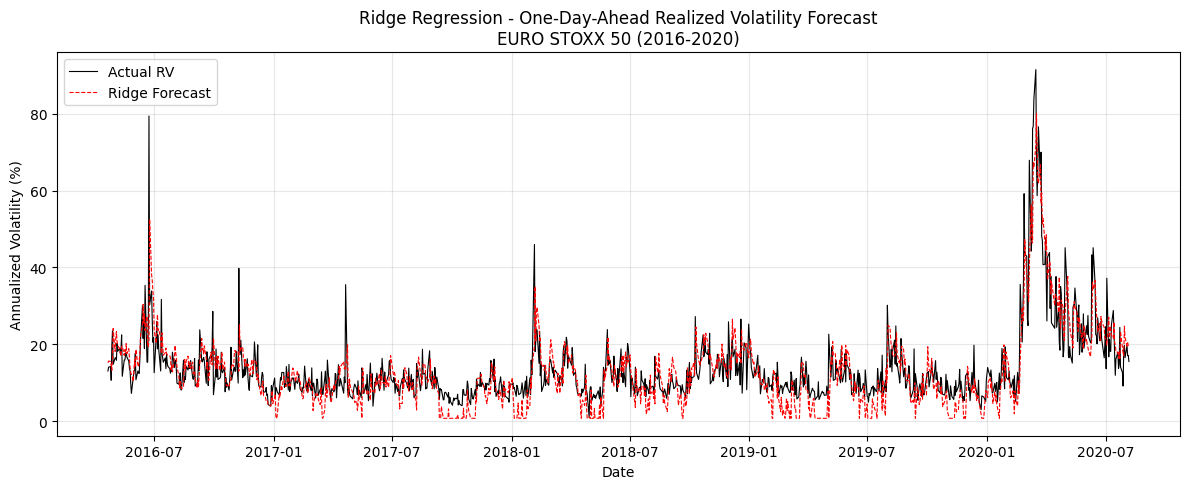


Summary of forecast errors:
Mean error:  6.830443e-06
RMSE:        1.435724e-04
MAE:         5.615166e-05
Average coefficient L2 norm in rolling estimation: 0.000106


In [8]:
results_plot_RR = pd.DataFrame({
    'Actual': np.sqrt(results_RR['RV_actual'] * 252) * 100,
    'Forecast': np.sqrt(results_RR['RV_forecast'] * 252) * 100
}, index=results_RR.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot_RR['Actual'], label='Actual RV', color='black', linewidth=0.8)
ax.plot(results_plot_RR['Forecast'], label='Ridge Forecast', color='red', linewidth=0.8, linestyle='--')
ax.set_title('Ridge Regression - One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016-2020)', fontsize=12)
ax.set_ylabel('Annualized Volatility (%)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nSummary of forecast errors:')
print(f'Mean error:  {errors_RR.mean():.6e}')
print(f'RMSE:        {np.sqrt(mse_RR):.6e}')
print(f'MAE:         {errors_RR.abs().mean():.6e}')
print(f'Average coefficient L2 norm in rolling estimation: {np.mean(coef_norm_path):.6f}')

## 9. Cross-Model Comparison Within the MALL Regularized Family

The final section compares the saved MSE summaries for `RR`, `LA`, and `EN` on the same MALL test period. We do not benchmark against a MALL HAR notebook here because the current task is limited to the regularized linear models.

In [9]:
forecast_path = '/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MALL'
summary_frames = []
missing_models = []
for model in ['RR', 'LA', 'EN']:
    file_path = os.path.join(forecast_path, f'mse_summary_{model}.csv')
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        summary_frames.append(df)
    else:
        missing_models.append(model)

if missing_models:
    print('Waiting for all three regularized-model summaries to exist.')
    print(f'Missing summaries: {missing_models}')

if summary_frames:
    comparison = pd.concat(summary_frames, ignore_index=True).set_index('Model')
    comparison = comparison[['MSE', 'RMSE', 'MAE', 'Mean_Error']].sort_values('MSE')
    comparison['Rank by MSE'] = np.arange(1, len(comparison) + 1)
    comparison = comparison[['Rank by MSE', 'MSE', 'RMSE', 'MAE', 'Mean_Error']]

    print('Test-set comparison across RR, LA, and EN on the MALL feature set:')
    display(comparison)


Waiting for all three regularized-model summaries to exist.
Missing summaries: ['LA', 'EN']
Test-set comparison across RR, LA, and EN on the MALL feature set:


,Rank by MSE,MSE,RMSE,MAE,Mean_Error
Model,,,,,
RR,1,2.061305e-08,0.000144,0.000056,0.000007
